In [111]:
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [112]:
#Define our dataset 
dataset = [11,10,12,14,12,15,14,13,15,102,12,14,17,19,107,10,13,12,14,12,108,12,11,14,13,15,10,15,12,10,14,13,15,10]

(array([31.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.]),
 array([ 10. ,  19.8,  29.6,  39.4,  49.2,  59. ,  68.8,  78.6,  88.4,
         98.2, 108. ]),
 <BarContainer object of 10 artists>)

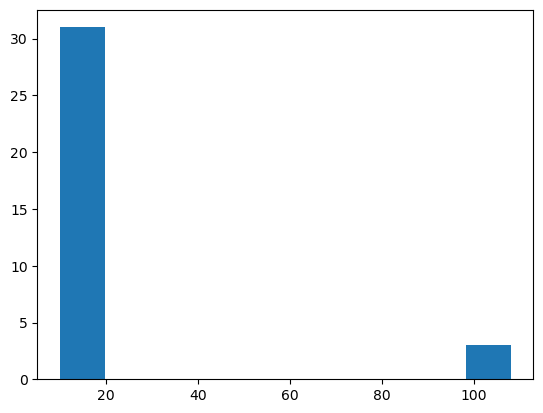

In [113]:
#We want to see the histogram  plot of the dataset
plt.hist(dataset)

<h1><b>OUTLIERS</b></h1><br>
we want to find outliers <br> 
We will gonna use z-scores to detect outliers<br>
Say any value outside of 3rd std is our outlier<br>

z_score = (x-x_bar)/std<br>
x is the value for which we want to find z_score

In [114]:
outliers=[]
def detect_outliers(data):
    threshold = 3 # 3rd standard deviation
    mean = np.mean(data)
    std = np.std(data)

    for x in data:
        z_score = (x-mean)/std
        if np.abs(z_score)>threshold:
            outliers.append(x)
    return outliers         

In [115]:
detect_outliers(dataset)

[102, 107, 108]

##IQR  
1.Sort the dataset (smallest to largest)  
2.Get the Q1 and Q2  
3.calculate IQR(Q3-Q1)  
4.Find lower fence(Q1-1.5*IQR)  
5.Find Higher Fence(Q3+1.5*IQR)  


In [116]:
sorted_dataset = sorted(dataset)
print(sorted_dataset)

[10, 10, 10, 10, 10, 11, 11, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 17, 19, 102, 107, 108]


In [117]:
Q1,Q3 = np.percentile(dataset,[25,75])
print(Q1,Q3)

12.0 15.0


In [118]:
IQR = Q3-Q1
print(IQR)

3.0


In [119]:
#Find Lower Fence and Higher Fence or more Formally min and max
min = Q1 - (1.5*IQR)
max = Q3 + (1.5*IQR)
print(min,max)

7.5 19.5


In [120]:
outliers=[]
def get_outliers(data,min,max):
    for x in data:
        if x < min or x > max:
           outliers.append(x)
    return outliers


In [121]:
get_outliers(dataset,min,max)

[102, 107, 108]

<Axes: >

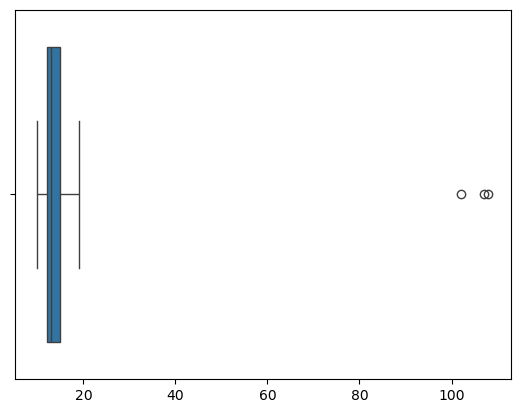

In [122]:
import seaborn as sns
sns.boxplot(x=sorted_dataset)